In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn import preprocessing
from sklearn.feature_selection import RFECV

# For 2D analysis
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import csv
import time
import glob

# Datasize in KB
data_size_kb = {'4mb': 4096, '16mb': 16384, '64mb': 65536,
            '256mb': 262144, '512mb': 524288, '1gb': 1048576,
            '5gb': 5242880, '50gb': 52428800, '100gb': 104857600,
            '300gb': 314572800,}

# Key Parameters
IOR_PARAMS = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesize', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', 'bwMiB', "storageType"]


## Bandwidth Prediction from IOR to Workflow
### Key parameters from IOR
Parameters for emulation:
- D: Total I/O size per task per operation
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: Bandwidth calculated from TIO/T
### Special note for IOR
IOR calculates bwMiB, but the bwMiB is little slower than the (aggregate filesize)/totalTime, but not much difference, particularly in the `totalTime=openTimewrRdTime+closetime`

### Key parameters from workflow
Parameters for characteristics
- D: Total I/O size per task per operation
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, calculate from A=D/C [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: Bandwidth calculated from TIO/T

### Perf Modeling Parameters
- a: Performance change when total data size reaches memory buffer cache of system.
- b: Performance change when  total data size reaches memory size of system. (Constant value)
- v: Performance variation due to shared storage resource. 
(The peak variation in the system. Measure with IOR.)
Deception BeeGFS: run at off hour to keep below 20% variation.
Options: (1) User/system admin to ensure the variation percentage; 
(2) Obtain variation with IOR emulation (possible over 20%)

- r: Range of expected performance: Make correct choice with given storage options.

- LPMR: Layered performance matching number for comparing application storage choice.
- w: Weight of a application LPMR. (Total data size, cost of moving data)


In [2]:
def file_size_to_bytes(file_size):
    # Translate KiB, MiB, and GiB to bytes
    size_num = float(file_size.split(" ")[0])
    size_unit = file_size.split(" ")[1]
    if size_unit == "KiB":
        return size_num * 1024
    elif size_unit == "MiB":
        return size_num * 1024 * 1024
    elif size_unit == "GiB":
        return size_num * 1024 * 1024 * 1024
    else:
        return int(size_num)

def get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS):


    # Create a dataframe for storing ior parameters
    ior_df = pd.DataFrame(columns=IOR_PARAMS)

    # Load Json files
    for jfile in ior_test_json_files:
        with open(jfile) as f:
            try:
                data = json.load(f)
            except:
                print("Error reading file: ", jfile)
                continue
            # print(jfile)
            
            # Write then Read
            ior_options = data['tests'][0]["Options"]
            IOR_PARAMS = data['tests'][0]["Parameters"]

            # Add write statistics first
            tmp_write_stat = {}
            ior_write_summary = data['summary'][0]
            tmp_write_stat['randomOffset'] = IOR_PARAMS['randomOffset']
            tmp_write_stat['aggregateFilesize'] = file_size_to_bytes(ior_options['aggregate filesize'])
            tmp_write_stat['numTasks'] = ior_write_summary['numTasks']
            tmp_write_stat['tasksPerNode'] = ior_write_summary['tasksPerNode']
            tmp_write_stat['numNodes'] = tmp_write_stat['numTasks']/tmp_write_stat['tasksPerNode']
            tmp_write_stat['transferSize'] = ior_write_summary['transferSize']
            if ior_write_summary['operation'] == "write":
                tmp_write_stat['operation'] = 0
            else:
                tmp_write_stat['operation'] = -1
            tmp_write_stat['totalTime'] = ior_write_summary['MeanTime'] # only 1 operation per test
            tmp_write_stat['bwMiB'] = ior_write_summary['bwMeanMIB'] # only 1 operation per test
            tmp_write_stat['storageType'] = storage_type
            # Add tmp_write_stat to df
            ior_df = ior_df._append(tmp_write_stat, ignore_index=True)

            # Add read statistics
            tmp_read_stat = {}
            ior_read_summary = data['summary'][1]
            tmp_read_stat['randomOffset'] = IOR_PARAMS['randomOffset']
            tmp_read_stat['aggregateFilesize'] = file_size_to_bytes(ior_options['aggregate filesize'])
            tmp_read_stat['numTasks'] = ior_read_summary['numTasks']
            tmp_read_stat['tasksPerNode'] = ior_read_summary['tasksPerNode']
            tmp_read_stat['numNodes'] = tmp_read_stat['numTasks']/tmp_read_stat['tasksPerNode']
            tmp_read_stat['transferSize'] = ior_read_summary['transferSize']
            if ior_read_summary['operation'] == "read":
                tmp_read_stat['operation'] = 1
            else:
                tmp_read_stat['operation'] = -1
            tmp_read_stat['totalTime'] = ior_read_summary['MeanTime']
            tmp_read_stat['bwMiB'] = ior_read_summary['bwMeanMIB']
            tmp_read_stat['storageType'] = storage_type
            # Add tmp_read_stat to df
            ior_df = ior_df._append(tmp_read_stat, ignore_index=True)

    # encode string to numbers
    le = preprocessing.LabelEncoder()
    for col in ior_df.columns:
        if pd.api.types.is_string_dtype(ior_df[col]):
            ior_df[col] = le.fit_transform(ior_df[col])

    # print(ior_df.head(5))

    return ior_df

def plot_heatmap(corrM,outfile):
    plt.figure(figsize=(14, 8))
    #labels = list(corrM.columns)
    plt.subplots_adjust(bottom=0.19)

    # # use only lower triangle
    # corrM = corrM.where(np.triu(np.ones(corrM.shape)).astype(np.bool))

    ## plot all correlation heatmap
    map = sns.heatmap(corrM, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='grey', cmap='BrBG') #annot=True,
    map.set_title('Correlation Matrix Heatmap', fontdict={'fontsize':12}, pad=12)
    #plt.show()
    out_file=f'{outfile}.png'
    plt.savefig(out_file)
    plt.clf()

def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop
    
def corrM_sorted_csv(corrM, outfile):
  n=5
  au_corr = corrM.corr().abs().unstack()
  labels_to_drop = get_redundant_pairs(corrM)
  au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
  sorted_corrM = au_corr[0:n]

  out_file= outfile
  sorted_corrM.to_csv(out_file)

def corr_matrix(df,outname=""):

    # calculte correlation matrix
    corrM = df.corr()

    corrM.to_csv(f'{outname}.csv')
    plot_heatmap(corrM,outname)
    #corrM_sorted_csv(corrM, f'sorted_{outname}.csv')

def _2d_trend(X, y, x_label="x-axis", y_label="bwMiB", title=""):
        X = X.reshape(-1, 1)
        # poly = PolynomialFeatures(degree=2)
        poly = PolynomialFeatures(degree=1)
        poly_data = poly.fit_transform(X)
        model = LinearRegression()
        model.fit(poly_data,y)
        coef = model.coef_
        intercept = model.intercept_
        plt.scatter(X,y,color='red')
        plt.plot(X,model.predict(poly.fit_transform(X)),color='blue')
        plt.legend(['Original','Prediction'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        plt.show()

def _3d_trend(x,y,z, title=""):
    # ref: https://stackoverflow.com/questions/2298390/fitting-a-line-in-3d
    data = np.concatenate((x[:, np.newaxis], 
                        y[:, np.newaxis], 
                        z[:, np.newaxis]), 
                        axis=1)
    data = data.astype('float64')

    # Calculate the mean of the points, i.e. the 'center' of the cloud
    datamean = data.mean(axis=0)
    print(datamean)

    # Do an SVD on the mean-centered data.
    # full_matrices=False reduce memory
    uu, dd, vv = np.linalg.svd(data - datamean, full_matrices=False)

    # Get the sptread of data with mean 0 from all axis
    x_min = np.min(data[:,0])
    y_min = np.min(data[:,1])
    z_min = np.min(data[:,2])

    x_max = np.max(data[:,0])
    y_max = np.max(data[:,1])
    z_max = np.max(data[:,2])

    low_bound = min(x_min, y_min, z_min)
    high_bound = max(x_max, y_max, z_max)

    # Now vv[0] contains the first principal component, i.e. the direction
    # vector of the 'best fit' line in the least squares sense.
    # Adjust axist limits (Optional)
    linepts = vv[0] * np.mgrid[low_bound:high_bound:2j][:, np.newaxis]
    # shift by the mean to get the line in the right place
    linepts += datamean

    # Verify that everything looks right.

    # import mpl_toolkits.mplot3d as m3d
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter3D(*data.T)
    ax.plot3D(*linepts.T)
    # ax.scatter3D(data[:,0], data[:,1], data[:,2])
    ax.set_xlabel("transferSize")
    ax.set_ylabel("aggregateFilesize")
    ax.set_zlabel("bwMiB")
    ax.set_title(title)
    plt.show()



Storage Type:  beegfs_ior


  operation randomOffset transferSize  aggregateFilesize numTasks  totalTime  \
0         0            0     16777216       1.073742e+09        1     4.5612   
1         1            0     16777216       1.073742e+09        1     0.6380   
2         0            0         4096       2.684355e+08        1     0.3765   
3         1            0         4096       2.684355e+08        1     0.3287   
4         0            0     16777216       5.368709e+09        1     4.5484   

   numNodes tasksPerNode      bwMiB  storageType  
0       1.0            1   224.5038            0  
1       1.0            1  1604.9508            0  
2       1.0            1   679.9221            0  
3       1.0            1   778.7760            0  
4       1.0            1  1125.6677            0  


<Figure size 1400x800 with 0 Axes>

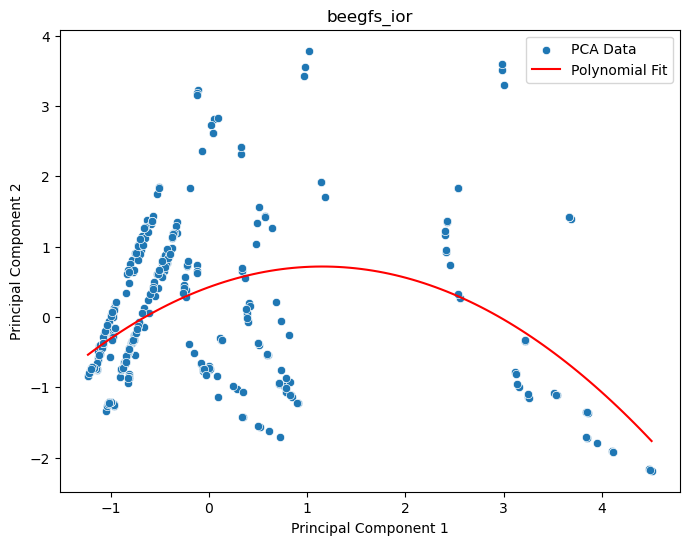

Polynomial fit parameters: a=-0.22070366514536377, b=0.5086551058767395, c=0.42465958210235155
Reconstruction error (MSE): 0.186027813537373
Explained variance by principal components: [0.38482332 0.24312106]


/people/tang584/.conda/envs/pyflextrkr/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


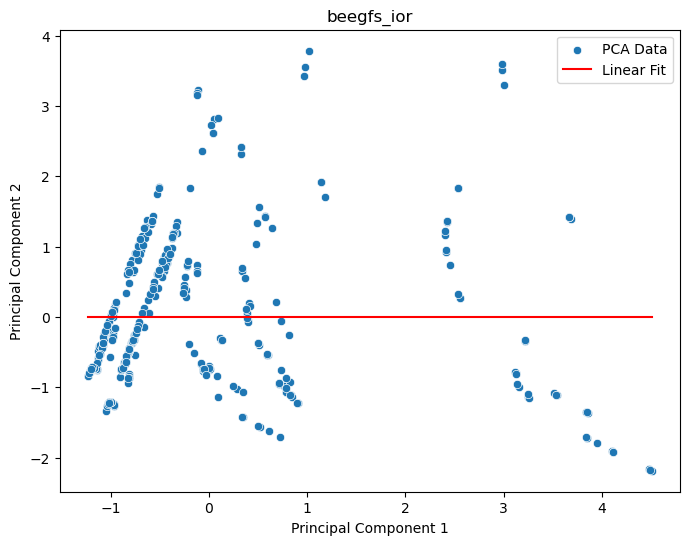

Linear fit parameters: intercept=1.8797426871960315e-17, slope=1.5643439094582412e-16
Reconstruction error (MSE): 0.186027813537373
Explained variance by principal components: [0.38482332 0.24312106]
Storage Type:  beegfs_pior
Error reading file:  ./ior_data/beegfs_pior_buffered_saved/pior_4k_50gb_n32_2.json
  operation randomOffset transferSize  aggregateFilesize numTasks  totalTime  \
0         0            0     16777216       4.294967e+09      128     0.9228   
1         1            0     16777216       4.294967e+09      128     0.4687   
2         0            0         1024       1.073742e+09        8     0.6121   
3         1            0         1024       1.073742e+09        8     0.2522   
4         0            0         4096       5.368709e+10       32     9.4066   

   numNodes tasksPerNode      bwMiB  storageType  
0       1.0          128  4438.8193            0  
1       1.0          128  8739.5731            0  
2       1.0            8  1672.9722            0  
3    

<Figure size 1400x800 with 0 Axes>

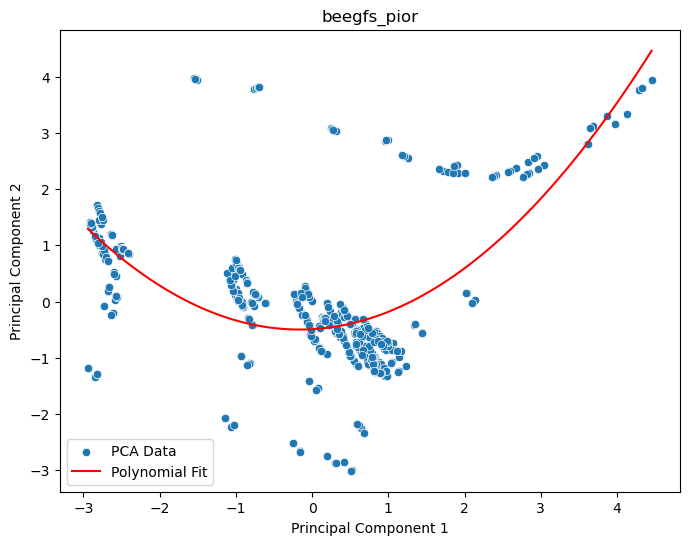

Polynomial fit parameters: a=0.2324347350171162, b=0.07654904807162566, c=-0.49236174152493484
Reconstruction error (MSE): 0.30436593185510363
Explained variance by principal components: [0.30261136 0.26258017]


/people/tang584/.conda/envs/pyflextrkr/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


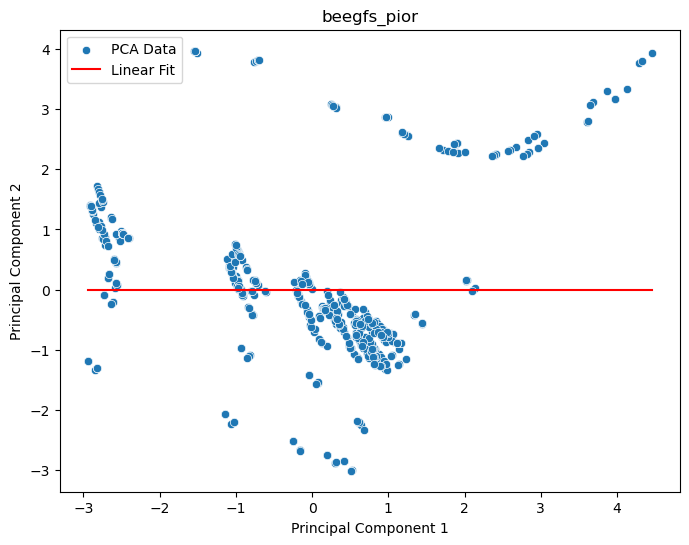

Linear fit parameters: intercept=-7.177199351112125e-17, slope=2.441293394537965e-16
Reconstruction error (MSE): 0.3043659318551036
Explained variance by principal components: [0.30261136 0.26258017]
Storage Type:  localssd_ior
  operation randomOffset transferSize  aggregateFilesize numTasks  totalTime  \
0         0            0     16777216       1.073742e+09        1     1.0864   
1         1            0     16777216       1.073742e+09        1     0.1232   
2         0            0         4096       2.684355e+08        1     0.3587   
3         1            0         4096       2.684355e+08        1     0.0557   
4         0            0     16777216       5.368709e+09        1     9.6490   

   numNodes tasksPerNode      bwMiB  storageType  
0       1.0            1   942.5850            0  
1       1.0            1  8312.5436            0  
2       1.0            1   713.6525            0  
3       1.0            1  4594.4891            0  
4       1.0            1   530.6274 

<Figure size 1400x800 with 0 Axes>

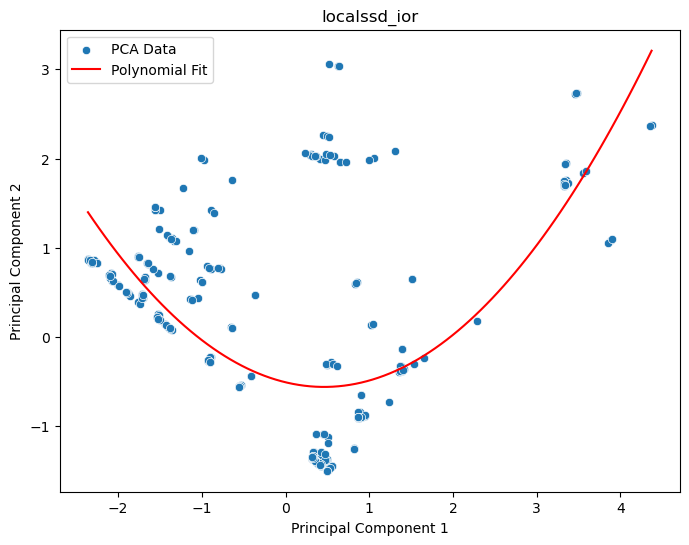

Polynomial fit parameters: a=0.24606226594542782, b=-0.22617072706497432, c=-0.5069661456096808
Reconstruction error (MSE): 0.1544887415990283
Explained variance by principal components: [0.4120633  0.27895922]


/people/tang584/.conda/envs/pyflextrkr/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


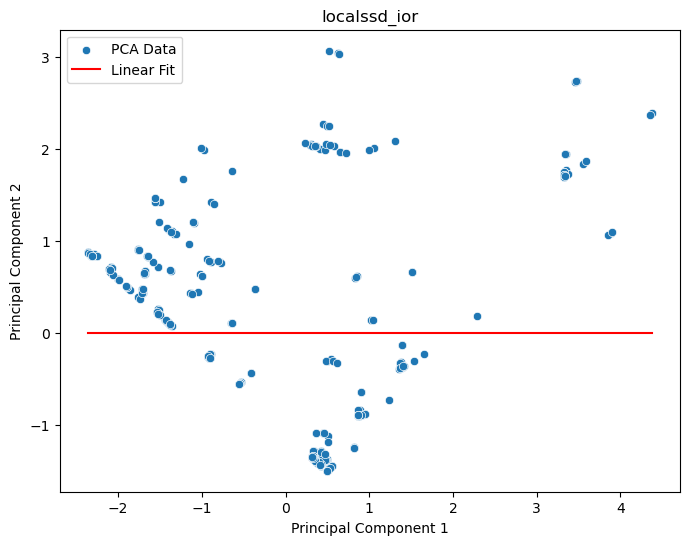

Linear fit parameters: intercept=-1.4098070153970238e-17, slope=5.569617825683762e-17
Reconstruction error (MSE): 0.1544887415990283
Explained variance by principal components: [0.4120633  0.27895922]
Storage Type:  localssd_pior
  operation randomOffset transferSize  aggregateFilesize numTasks  totalTime  \
0         0            0     67108864       5.153961e+10       64   118.1576   
1         1            0     67108864       5.153961e+10       64     0.6154   
2         0            0     16777216       4.294967e+09      128     8.5607   
3         1            0     16777216       4.294967e+09      128     0.1042   
4         0            0         1024       4.294967e+09        8     8.5821   

   numNodes tasksPerNode       bwMiB  storageType  
0       1.0           64    415.9866            0  
1       1.0           64  79865.1780            0  
2       1.0          128    478.4679            0  
3       1.0          128  39323.5761            0  
4       1.0            8    4

<Figure size 1400x800 with 0 Axes>

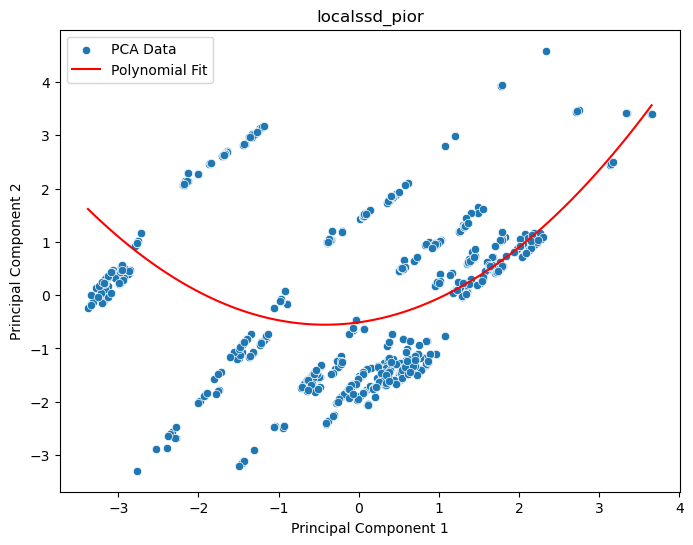

Polynomial fit parameters: a=0.24809299669489637, b=0.2087927406426946, c=-0.5104301171634575
Reconstruction error (MSE): 0.3070319135219333
Explained variance by principal components: [0.29391635 0.26746663]


/people/tang584/.conda/envs/pyflextrkr/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


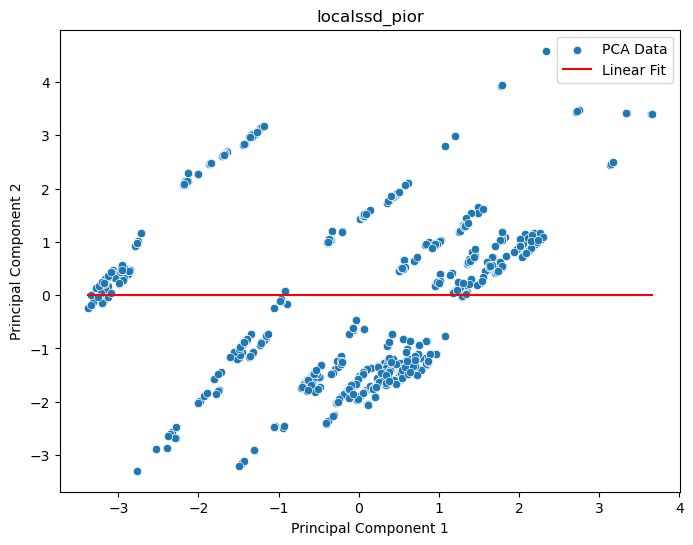

Linear fit parameters: intercept=-6.799452016843064e-17, slope=5.2458009761320674e-17
Reconstruction error (MSE): 0.3070319135219333
Explained variance by principal components: [0.29391635 0.26746663]


In [5]:

def _polynomial_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Define a polynomial function to fit
    def polynomial_func(x, a, b, c):
        return a * x**2 + b * x + c

    # Fit the polynomial curve
    params, _ = curve_fit(polynomial_func, pca_df['PC1'], pca_df['PC2'])

    # Predict values using the fitted curve
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_curve = polynomial_func(x_vals, *params)

    # Visualizing the PCA result and the fitted curve
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_curve, color='red', label='Polynomial Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Curve fit parameters
    print(f'Polynomial fit parameters: a={params[0]}, b={params[1]}, c={params[2]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')
    # # Optional: Display the reconstructed data
    # reconstructed_df = pd.DataFrame(reconstructed_data, columns=df.columns)
    # print("Original Data (first 5 rows):")
    # print(df.head())
    # print("Reconstructed Data (first 5 rows):")
    # print(reconstructed_df.head())

    # # Optional: Visualize the original vs reconstructed data
    # plt.figure(figsize=(12, 6))

    # # Original data
    # plt.subplot(1, 2, 1)
    # sns.heatmap(scaled_data, cmap='viridis', cbar=False)
    # plt.title('Original Data')

    # # Reconstructed data
    # plt.subplot(1, 2, 2)
    # sns.heatmap(reconstructed_data, cmap='viridis', cbar=False)
    # plt.title('Reconstructed Data')

def _linear_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Fit the linear regression model
    reg = LinearRegression()
    reg.fit(pca_df[['PC1']], pca_df['PC2'])

    # Predict values using the fitted model
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_line = reg.predict(x_vals.reshape(-1, 1))

    # Visualizing the PCA result and the fitted line
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_line, color='red', label='Linear Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Linear fit parameters
    print(f'Linear fit parameters: intercept={reg.intercept_}, slope={reg.coef_[0]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')


def analyze_ior_jsons(ior_data_path):
    # Get the list of JSON files from the directory
    ior_test_json_files = glob.glob(ior_data_path + "/*.json")

    # Get storage type from data_path name
    storage_type =  ior_data_path.split("/")[-1].split("_")[0] + "_" + ior_data_path.split("/")[-1].split("_")[1]
    print("Storage Type: ", storage_type)
    ior_df = get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS)
    print(ior_df.head(5))

    # print(ior_df.head(10))
    corr_matrix(ior_df, storage_type)

    _polynomial_fit_pca(ior_df, title=str(storage_type))
    _linear_fit_pca(ior_df, title=str(storage_type))

    return ior_df

ior_data_paths = [
    "./ior_data/beegfs_ior_buffered_saved",
    "./ior_data/beegfs_pior_buffered_saved",
    "./ior_data/localssd_ior_buffered_saved",
    "./ior_data/localssd_pior_buffered_saved",
]

master_ior_df = pd.DataFrame(columns=IOR_PARAMS)

for ior_data_path in ior_data_paths:
    master_ior_df = master_ior_df._append(analyze_ior_jsons(ior_data_path), ignore_index=True)
    # analyze_ior_jsons(ior_data_path)

    # Save the master dataframe to csv

master_ior_df.to_csv("master_ior_df.csv")



['../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps1/1_s_1n_SSD_t1', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps1/1_p_1n_SSD_t3', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps1/1_p_1n_SSD_t2']
  operation randomOffset  transferSize aggregateFilesize numTasks  totalTime  \
0         0            1    7788.25000             31153        1   0.000070   
1         1            1    8191.91228        2539476423        1   0.580282   
2         0            1    7807.75000             31231        1   0.000055   
3         1            1    8191.91228        2539476423        1   0.619769   
4         0            1    7785.25000             31141        1   0.000064   

   numNodes tasksPerNode         bwMiB  storageType  
0       1.0            1  4.425645e+08            0  
1       1.0            1  4.376283e+09            0  
2       1.0            1  5.636144e+08            0  
3       1.0            1  4.097455e+09            0  
4       1.0      

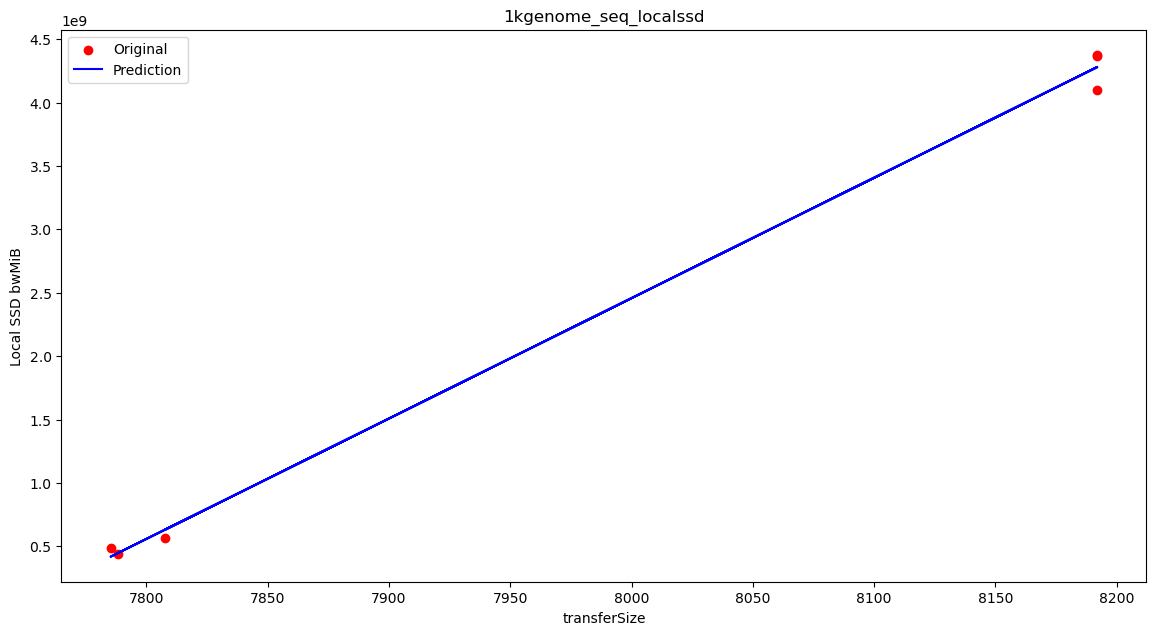

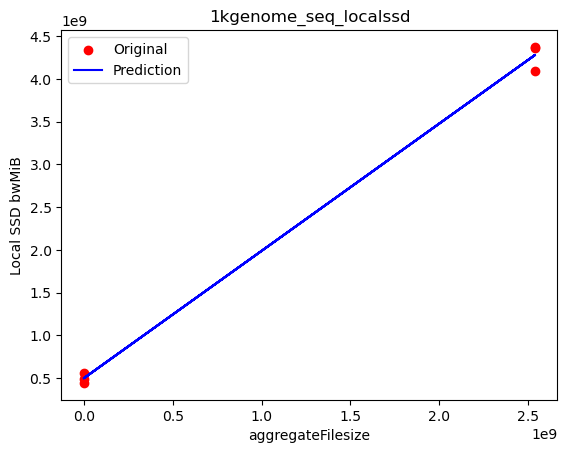

[7.99283114e+03 1.26975380e+09 2.38948323e+09]


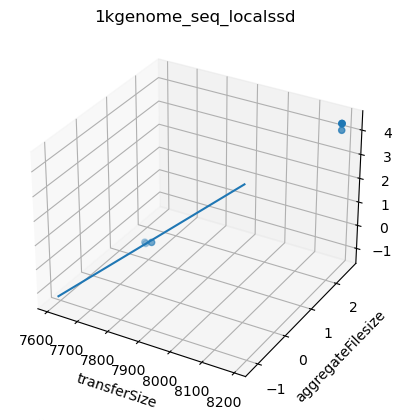

['../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps2/2_p_1n_SSD_t2', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps2/2_p_1n_SSD_t3', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps2/2_p_1n_SSD_t1']
  operation randomOffset  transferSize aggregateFilesize numTasks  totalTime  \
0         0            1    7792.00000             31168        1   0.000063   
1         1            1    8191.91228        2539476423        1   0.531306   
2         0            1    7772.50000             31090        1   0.000070   
3         1            1    8191.91228        2539476423        1   0.580723   
4         0            1    7762.75000             31051        1   0.000056   

   numNodes tasksPerNode         bwMiB  storageType  
0       1.0            1  4.935394e+08            0  
1       1.0            1  4.779690e+09            0  
2       1.0            1  4.431237e+08            0  
3       1.0            1  4.372958e+09            0  
4       1.0      

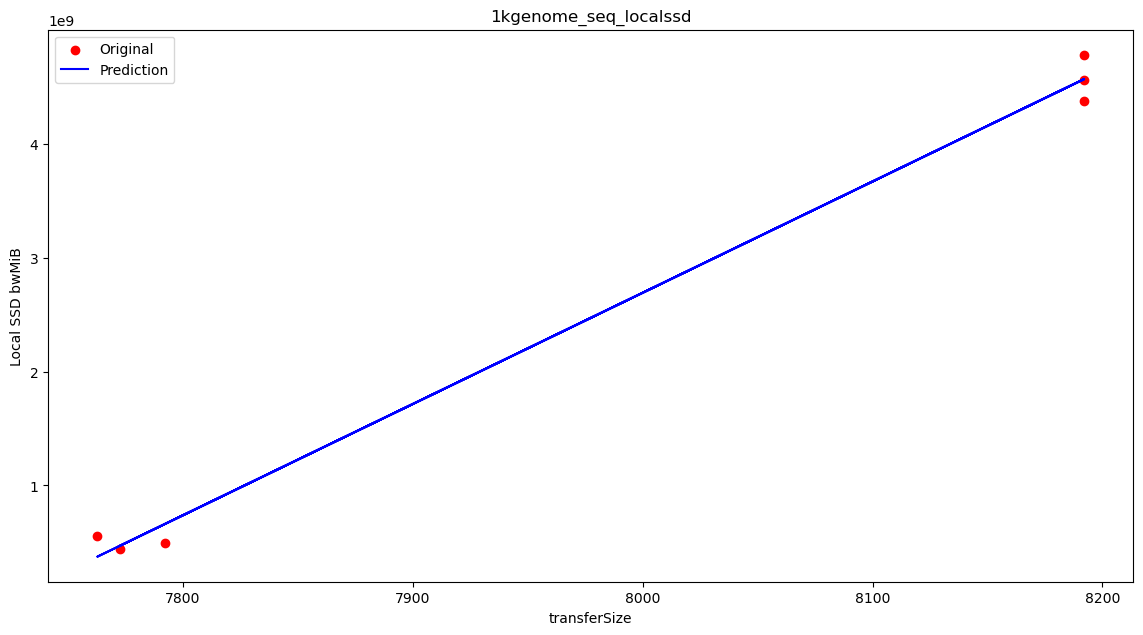

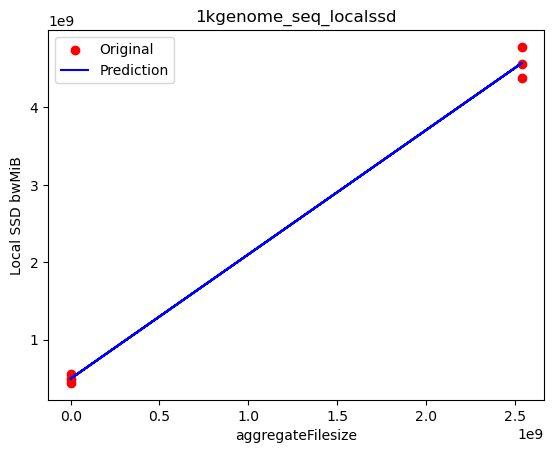

[7.98383114e+03 1.26975376e+09 2.53393823e+09]


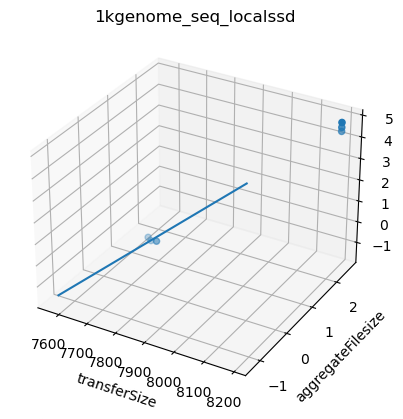

['../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps20/20_p_1n_SSD_t2', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps20/20_p_1n_SSD_t3', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps20/20_p_1n_SSD_t1']
  operation randomOffset  transferSize aggregateFilesize numTasks  totalTime  \
0         0            1   14243.50000             56974        1   0.000060   
1         1            1    8191.91228        2539476423        1   0.609386   
2         0            1   15457.25000             61829        1   0.000077   
3         1            1    8191.91228        2539476423        1   0.560016   
4         0            1   13621.00000             54484        1   0.000081   

   numNodes tasksPerNode         bwMiB  storageType  
0       1.0            1  9.554266e+08            0  
1       1.0            1  4.167269e+09            0  
2       1.0            1  8.018078e+08            0  
3       1.0            1  4.534648e+09            0  
4       1.0

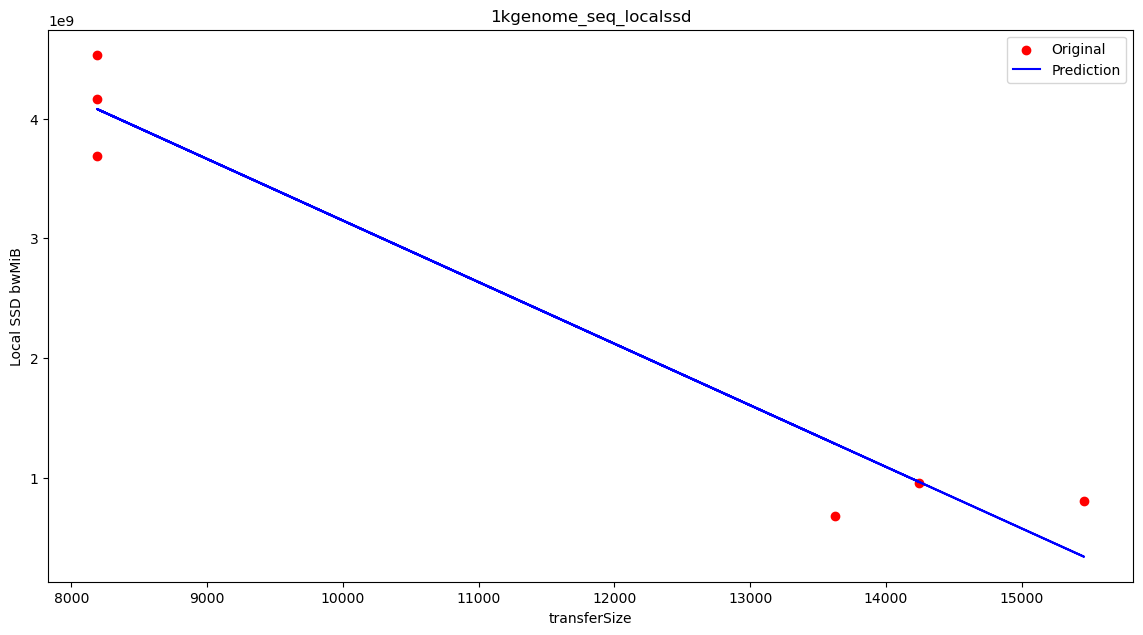

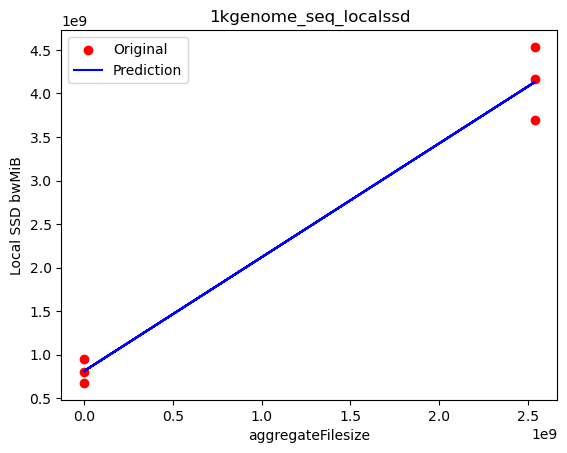

[1.13162478e+04 1.26976709e+09 2.47133913e+09]


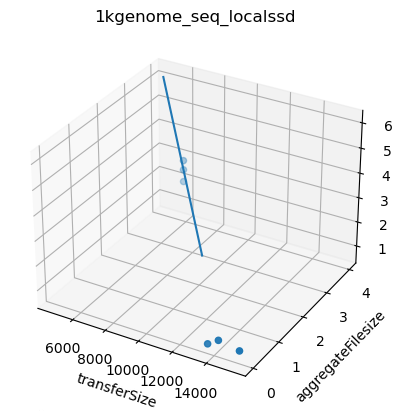

['../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps40/40_p_1n_SSD_t1', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps40/40_p_1n_SSD_t3', '../example_workflow/1kgenome/1000_tests/seq_1000_1n_ssd_ps40/40_p_1n_SSD_t2']
  operation randomOffset  transferSize aggregateFilesize numTasks  totalTime  \
0         0            1   7815.250000             31261        1   0.000046   
1         1            1   8191.921474        2539397354        1   0.930690   
2         0            1   7817.500000             31270        1   0.000070   
3         1            1   8191.912280        2539476423        1   0.860097   
4         0            1  14209.500000             56838        1   0.000060   

   numNodes tasksPerNode         bwMiB  storageType  
0       1.0            1  6.731192e+08            0  
1       1.0            1  2.728509e+09            0  
2       1.0            1  4.474046e+08            0  
3       1.0            1  2.952546e+09            0  
4       1.0

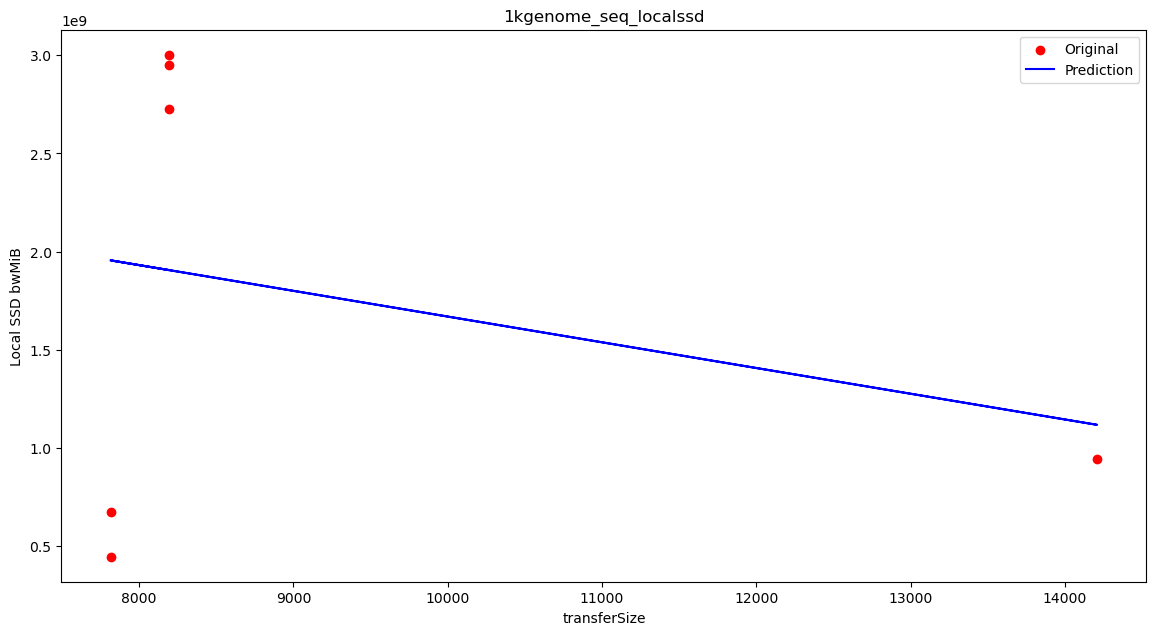

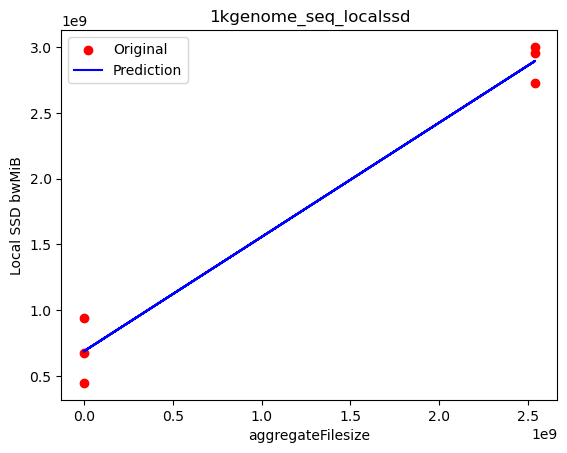

[9.06966754e+03 1.26973175e+09 1.79131393e+09]


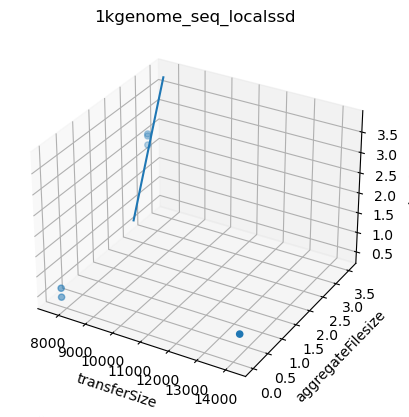

In [ ]:
# Load 1kgenome data
onekg_data_path = "../example_workflow/1kgenome/1000_tests"

seq_test_folder = ['seq_1000_1n_ssd_ps1', 
                'seq_1000_1n_ssd_ps2', 
                'seq_1000_1n_ssd_ps20',
                'seq_1000_1n_ssd_ps40']


# Key Parameters
wf_params = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesize', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', 'bwMiB', "storageType"]

target_tasks = ["python"] # omit srun from 1kgenome run



def is_sequential(numbers):
    if not numbers:  # Check if the list is empty
        return False

    sorted_numbers = sorted(numbers)  # Sort the numbers
    return all(sorted_numbers[i] + 1 == sorted_numbers[i + 1] for i in range(len(sorted_numbers) - 1))

def get_wf_result_df(tests, storage_type="localssd"):

    wf_df = pd.DataFrame(columns=wf_params)

    # Find folders ending with [t1, t2, t3] in the test_folders
    test_folders = glob.glob(f"{tests}/*")
    wf_trial_folders = [folder for folder in test_folders if folder.endswith("t1") or folder.endswith("t2") or folder.endswith("t3")]
    print(wf_trial_folders)
    
    for trial_folder in wf_trial_folders:
        # Find all json files in the trial folder
        # wf_json_files = glob.glob(f"{trial_folder}/*.json")


        datalife_jsons = glob.glob(f"{trial_folder}/*.datalife.json")

        # print(datalife_jsons)

        monitor_timer_stat = {}


        for datalife_json in datalife_jsons:
            with open(datalife_json) as f:
                datalife_data = json.load(f)
                # Get the first key
                task_name = list(datalife_data.keys())[0]

                # check if the task is in the target_tasks, or part of the target_tasks substring
                if any(task in task_name for task in target_tasks):
                    # print(f"Found task [{task_name}]")
                    # Select 'monitor', not 'system' and 'local'
                    monitor_timer_stat = datalife_data[task_name]['monitor']
                    # TODO: get one forf now
                    break
        # print(monitor_timer_stat)

        # Get write statistics
        monitor_timer_stat_write = monitor_timer_stat['write'] # list with [time_sec, op_cnt, io_size]
        tmp_write_stat = {}
        tmp_write_stat['aggregateFilesize'] = monitor_timer_stat_write[2]
        tmp_write_stat['numTasks'] = 1 # seq for now
        tmp_write_stat['tasksPerNode'] = 1 # seq for now
        tmp_write_stat['numNodes'] = tmp_write_stat['numTasks']/tmp_write_stat['tasksPerNode']
        tmp_write_stat['transferSize'] = monitor_timer_stat_write[2]/monitor_timer_stat_write[1]
        tmp_write_stat['operation'] = 0
        tmp_write_stat['totalTime'] = monitor_timer_stat_write[0]
        tmp_write_stat['bwMiB'] = monitor_timer_stat_write[2]/monitor_timer_stat_write[0]
        tmp_write_stat['storageType'] = storage_type

        w_blk_trace_jsons = glob.glob(f"{trial_folder}/*w_blk_trace.json")
        write_pattern = 0 # 0: seq, 1: rand        
        for w_blk_trace_json in w_blk_trace_jsons:
            with open(w_blk_trace_json) as f:
                w_blk_trace_data = json.load(f)
                # print(w_blk_trace_data)
                blk_list = w_blk_trace_data['io_blk_range']
                if not is_sequential(blk_list):
                    write_pattern =1
                    # For now only single read and write
                    break
        tmp_write_stat['randomOffset'] = write_pattern
        wf_df = wf_df._append(tmp_write_stat, ignore_index=True)

        # Get read statistics
        monitor_timer_stat_read = monitor_timer_stat['read']
        tmp_read_stat = {}
        tmp_read_stat['aggregateFilesize'] = monitor_timer_stat_read[2]
        tmp_read_stat['numTasks'] = 1
        tmp_read_stat['tasksPerNode'] = 1
        tmp_read_stat['numNodes'] = tmp_read_stat['numTasks']/tmp_read_stat['tasksPerNode']
        tmp_read_stat['transferSize'] = monitor_timer_stat_read[2]/monitor_timer_stat_read[1]
        tmp_read_stat['operation'] = 1
        tmp_read_stat['totalTime'] = monitor_timer_stat_read[0]
        tmp_read_stat['bwMiB'] = monitor_timer_stat_read[2]/monitor_timer_stat_read[0]
        tmp_read_stat['storageType'] = storage_type

        r_blk_trace_jsons = glob.glob(f"{trial_folder}/*r_blk_trace.json")
        read_pattern = 0
        for r_blk_trace_json in r_blk_trace_jsons:
            with open(r_blk_trace_json) as f:
                r_blk_trace_data = json.load(f)
                blk_list = r_blk_trace_data['io_blk_range']
                if not is_sequential(blk_list):
                    read_pattern =1
                    # For now only single read and write
                    break
        tmp_read_stat['randomOffset'] = read_pattern
        wf_df = wf_df._append(tmp_read_stat, ignore_index=True)

    # encode string to numbers
    le = preprocessing.LabelEncoder()
    for col in wf_df.columns:
        if pd.api.types.is_string_dtype(wf_df[col]):
            wf_df[col] = le.fit_transform(wf_df[col])

    # print(wf_df.head(5))

    return wf_df
    # break

for tests in seq_test_folder:
    storage_type = "1kgenome_seq_localssd"
    # io_size_dfs
    wf_df = get_wf_result_df(f"{onekg_data_path}/{tests}", storage_type=storage_type)
    print(wf_df.head(5))
    # Print size of df
    print(wf_df.shape)

    corr_matrix(wf_df, storage_type)

    _x1 = wf_df["transferSize"].values
    _x2 = wf_df["aggregateFilesize"].values
    _y = wf_df["bwMiB"].values

    _2d_trend(_x1,_y,x_label="transferSize", y_label="Local SSD bwMiB", title=str(storage_type))
    _2d_trend(_x2,_y,x_label="aggregateFilesize", y_label="Local SSD bwMiB", title=str(storage_type))
    _3d_trend(_x1,_x2,_y, title=str(storage_type))




In [ ]:
par_test_folder = ['par_1000_1n_ssd_ps1',
                'par_1000_1n_ssd_ps2',
                'par_1000_1n_ssd_ps20',
                'par_1000_1n_ssd_ps40']

for tests in par_test_folder:
    storage_type = "1kgenome_par_localssd"
    # io_size_dfs
    wf_df = get_wf_result_df(f"{onekg_data_path}/{tests}", storage_type=storage_type)
    print(wf_df.head(5))
    # Print size of df
    print(wf_df.shape)

    # Drop storage type for correlation matrix
    corr_matrix(wf_df, storage_type)


[]
Empty DataFrame
Columns: [operation, randomOffset, transferSize, aggregateFilesize, numTasks, totalTime, numNodes, tasksPerNode, bwMiB, storageType]
Index: []
(0, 10)
[]
Empty DataFrame
Columns: [operation, randomOffset, transferSize, aggregateFilesize, numTasks, totalTime, numNodes, tasksPerNode, bwMiB, storageType]
Index: []
(0, 10)
[]
Empty DataFrame
Columns: [operation, randomOffset, transferSize, aggregateFilesize, numTasks, totalTime, numNodes, tasksPerNode, bwMiB, storageType]
Index: []
(0, 10)
[]
Empty DataFrame
Columns: [operation, randomOffset, transferSize, aggregateFilesize, numTasks, totalTime, numNodes, tasksPerNode, bwMiB, storageType]
Index: []
(0, 10)


<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>